# Getting Started with Qiskit

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ionq-samples/getting-started/blob/main/qiskit.ipynb)

[Qiskit](https://qiskit.org/) is an open-source quantum computing framework developed by IBM for building, simulating, and running quantum circuits on real and simulated quantum devices.

In [2]:
%%capture

# First, we install the essential libraries to our current Python runtime.
# "%%capture" (above) captures and in this case, hides the output of this 
# cell, so you can comment it out if you need help debugging this step.

%pip install qiskit qiskit_ionq matplotlib pylatexenc

In [6]:
import os, qiskit_ionq
from getpass import getpass
import dotenv

dotenv.load_dotenv()

# Before you begin, get your API key from https://cloud.ionq.com/settings/keys
# If your API key is stored as "IONQ_API_KEY" in your local environment, this
# should find it. Otherwise you'll be prompted to enter your API key manually.

api_key = os.getenv('IONQ_API_KEY') or getpass('Enter your IonQ API key: ')
provider = qiskit_ionq.IonQProvider(api_key)
from qiskit_ionq import IonQProvider,ErrorMitigation
print(api_key)
#Call provider and set token value
provider = IonQProvider(token=api_key)
provider.backends()

# We need to specify a backend, which is where the circuit will be executed. In
# this case we're using the `ionq_simulator`, but if you have QPU access you
# can specify it here to run the job on a QPU directly.

qpu_backend = provider.get_backend("qpu.aria-1", gateset="native")

xmWCkOA5c9tZj3PTRFKwmzPR7jFAo7gI


In [23]:
from qiskit import QuantumCircuit

# Now we set up our circuit. In this case, we're creating a circuit with two
# qubits, applying an H gate to qubit-0, a CXGate to both, then measuring.

qc = QuantumCircuit(2, name="Qiskit Example Circuit")
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

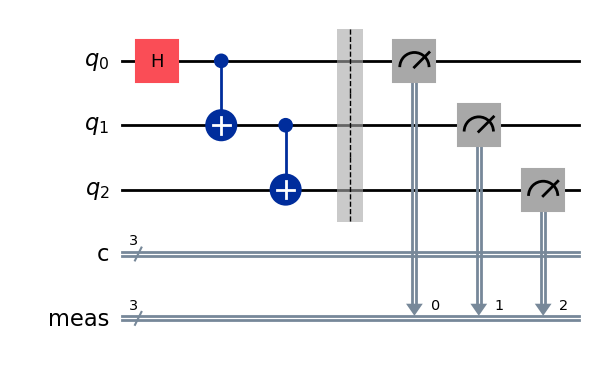

In [4]:
from qiskit import QuantumCircuit

# Now we set up our circuit. In this case, we're creating a circuit with two
# qubits, applying an H gate to qubit-0, a CXGate to both, then measuring.

qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()
qc.draw('mpl')

In [10]:
from qiskit.visualization import plot_histogram
from qiskit import transpile

# Now we'll send the job to our backend for processing.
qcT =  transpile(qc, qpu_backend,optimization_level=3)
job = qpu_backend.run(qcT, shots=1000, error_mitigation=ErrorMitigation.DEBIASING)

# And once the job has run, we can plot the results.



In [16]:
job.status()

<JobStatus.DONE: 'job has successfully run'>

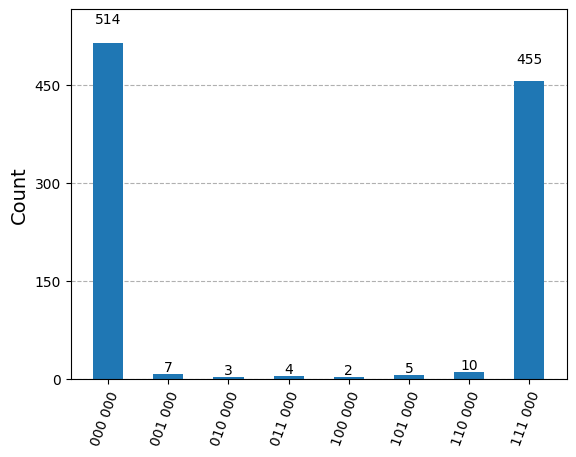

In [17]:
plot_histogram(job.result().get_counts())

## And that's a wrap!

To continue learning with Qiskit, check out more advanced examples here: https://github.com/ionq-samples/qiskit-getting-started